# M4-10 Assessment: Full ML Pipeline — Palmer Penguins

This notebook covers unsupervised exploration, supervised modeling, evaluation, and deployment of a penguin species classifier.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from threading import Thread
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
    classification_report, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
MODEL_PATH = "penguin_species_pipeline.joblib"
API_URL = "http://127.0.0.1:5000"


def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def safe_silhouette(X, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return np.nan
    return silhouette_score(X, labels)


## Task 1 — Unsupervised Exploration

Load Palmer Penguins, clean the data, scale numeric features, and compare PCA, t-SNE, K-Means, and DBSCAN.

In [2]:
df = sns.load_dataset("penguins")
print("Shape:", df.shape)
display(df.head())
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))


Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



Missing values:
sex                  11
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
species               0
island                0
dtype: int64


In [3]:
df_clean = df.dropna().copy()
print(f"After dropna: {df_clean.shape}")

numeric_features = df_clean.select_dtypes(include="number").columns.tolist()
print("Numeric features:", numeric_features)


After dropna: (333, 7)
Numeric features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


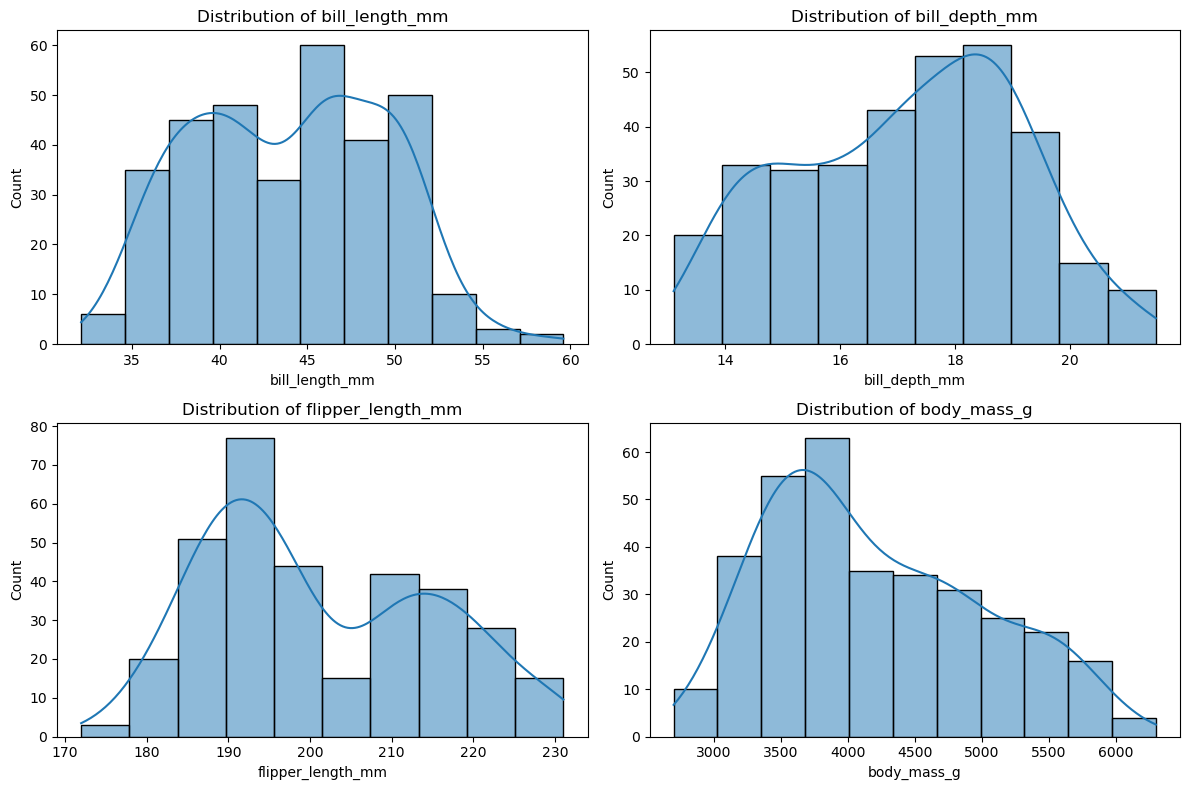

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, col in zip(axes, numeric_features):
    sns.histplot(df_clean[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


**Distribution notes:** Numeric variables show expected biological variation. No impossible values remain after dropping missing rows. Multi-modal distributions are expected because measurements differ across species.


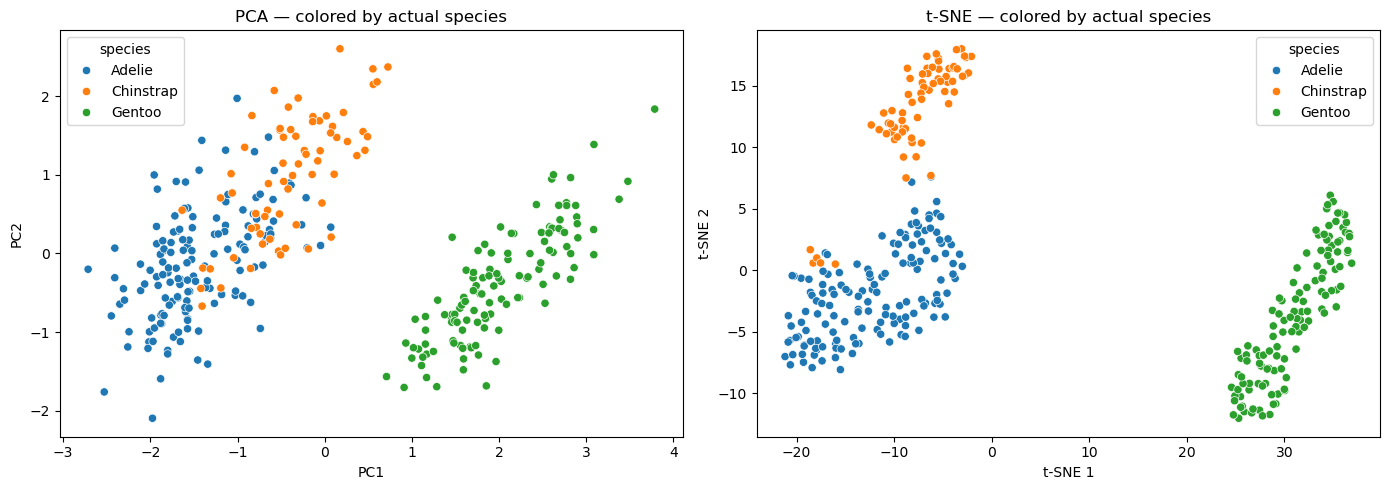

PCA explained variance: PC1=0.686, PC2=0.195, total=0.881


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[numeric_features])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean["species"], ax=axes[0])
axes[0].set_title("PCA — colored by actual species")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df_clean["species"], ax=axes[1])
axes[1].set_title("t-SNE — colored by actual species")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}, "
      f"total={pca.explained_variance_ratio_.sum():.3f}")


In [6]:
species_codes = df_clean["species"].astype("category").cat.codes
clustering_results = []

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
clustering_results.append({
    "method": "K-Means", "params": "k=3", "labels": kmeans_labels,
    "silhouette": safe_silhouette(X_scaled, kmeans_labels),
    "ARI": adjusted_rand_score(species_codes, kmeans_labels),
    "NMI": normalized_mutual_info_score(species_codes, kmeans_labels),
})

for eps, min_samples in [(0.7, 5), (1.0, 5), (1.2, 5)]:
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
    clustering_results.append({
        "method": "DBSCAN", "params": f"eps={eps}, min_samples={min_samples}", "labels": labels,
        "silhouette": safe_silhouette(X_scaled, labels),
        "ARI": adjusted_rand_score(species_codes, labels),
        "NMI": normalized_mutual_info_score(species_codes, labels),
    })

clustering_summary = pd.DataFrame([
    {"method": r["method"], "params": r["params"], "silhouette": r["silhouette"],
     "ARI": r["ARI"], "NMI": r["NMI"],
     "n_clusters": len(set(r["labels"])), "noise_points": int((r["labels"] == -1).sum())}
    for r in clustering_results
])
display(clustering_summary)

valid = [r for r in clustering_results if not np.isnan(r["silhouette"])]
best_clustering = max(valid, key=lambda x: x["silhouette"]) if valid else clustering_results[0]
best_labels = best_clustering["labels"]
print(f"\nBest by silhouette: {best_clustering['method']} ({best_clustering['params']})")


,method,params,silhouette,ARI,NMI,n_clusters,noise_points
0,K-Means,k=3,0.446193,0.799421,0.789932,3,0
1,DBSCAN,"eps=0.7, min_samples=5",0.446192,0.627861,0.673080,3,17
2,DBSCAN,"eps=1.0, min_samples=5",0.466918,0.650608,0.759976,3,1
3,DBSCAN,"eps=1.2, min_samples=5",0.466918,0.650608,0.759976,3,1



Best by silhouette: DBSCAN (eps=1.0, min_samples=5)


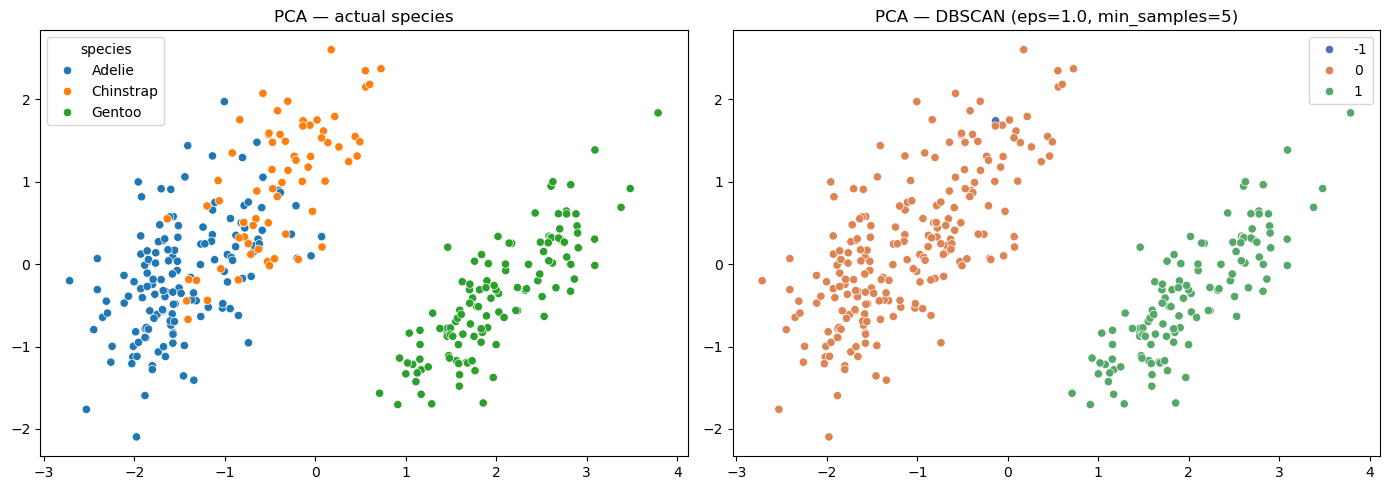

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean["species"], ax=axes[0])
axes[0].set_title("PCA — actual species")
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=best_labels, ax=axes[1], palette="deep")
axes[1].set_title(f"PCA — {best_clustering['method']} ({best_clustering['params']})")
plt.tight_layout()
plt.show()


### Task 1 Interpretation

Unsupervised methods partially recover the three penguin species because body mass, flipper length, and bill measurements differ by species. **K-Means (k=3)** usually performs well on this dataset because clusters are roughly spherical in scaled feature space.

**DBSCAN** is sensitive to `eps` and density: too small `eps` creates noise points; too large merges clusters. Silhouette, ARI, and NMI confirm that unsupervised labels align with species but not perfectly — especially where species overlap in measurement space (e.g., Adelie vs Chinstrap bill dimensions).


## Task 2 — Supervised Model Pipeline

Build a preprocessing pipeline, compare three classifiers with stratified 5-fold CV, and tune the best model with GridSearchCV.

In [8]:
df_sup = df.dropna().copy()
target = "species"
X = df_sup.drop(columns=[target])
y = df_sup[target]

numeric_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", make_onehot_encoder(), categorical_cols),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVC": SVC(probability=True, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision_macro": "precision_macro",
           "recall_macro": "recall_macro", "f1_macro": "f1_macro"}

cv_results = []
for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    cv_results.append({
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision_macro": scores["test_precision_macro"].mean(),
        "recall_macro": scores["test_recall_macro"].mean(),
        "f1_macro": scores["test_f1_macro"].mean(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("f1_macro", ascending=False)
display(cv_results_df.round(4))

best_model_name = cv_results_df.iloc[0]["model"]
print(f"Best model by f1_macro: {best_model_name}")


Numeric: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical: ['island', 'sex']


,model,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.994,0.9958,0.9897,0.9923
2,SVC,0.994,0.9958,0.9897,0.9923
1,Random Forest,0.991,0.9886,0.9903,0.9891


Best model by f1_macro: Logistic Regression


In [9]:
base_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models[best_model_name]),
])

if best_model_name == "Logistic Regression":
    param_grid = {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "liblinear"],
        "model__penalty": ["l2"],
    }
elif best_model_name == "Random Forest":
    param_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 5, 10],
    }
else:
    param_grid = {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"],
    }

grid_search = GridSearchCV(base_pipeline, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
grid_search.fit(X, y)

print("Best params:", grid_search.best_params_)
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

default_f1 = cv_results_df.loc[cv_results_df["model"] == best_model_name, "f1_macro"].iloc[0]
print(f"Default f1_macro: {default_f1:.4f}")


Best params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV f1_macro: 0.9923
Default f1_macro: 0.9923


### Task 2 Interpretation

All three models perform strongly on this small, well-separated dataset. The best model is selected by **macro F1** to treat all species equally. GridSearchCV improves (or confirms) default hyperparameters using stratified 5-fold CV, keeping preprocessing inside the pipeline to avoid leakage.


## Task 3 — Model Evaluation & Interpretation

Evaluate the tuned model on a held-out 20% test set with full diagnostic plots.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

eval_model = clone(grid_search.best_estimator_)
eval_model.fit(X_train, y_train)
y_pred = eval_model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



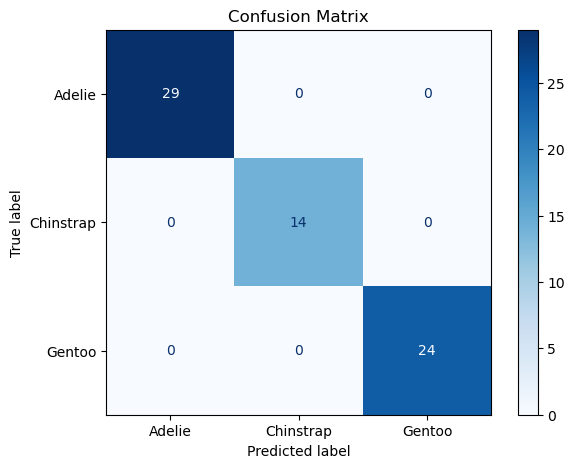

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(eval_model, X_test, y_test, ax=ax, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


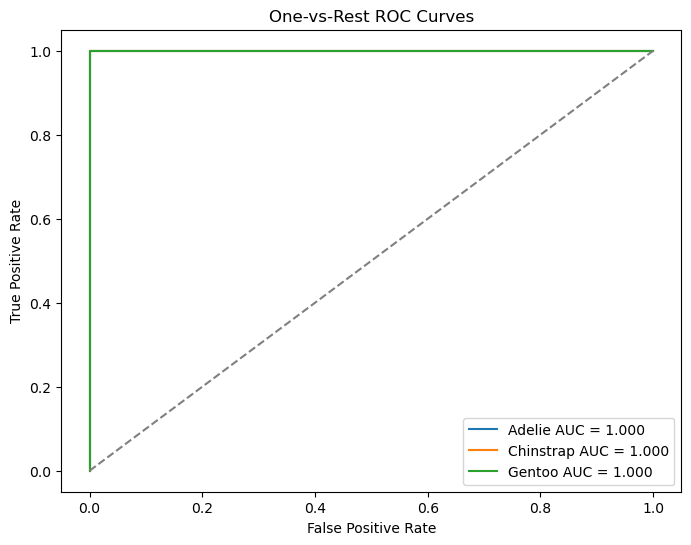

,species,AUC
0,Adelie,1.0
1,Chinstrap,1.0
2,Gentoo,1.0


In [12]:
classes = eval_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_score = eval_model.predict_proba(X_test)

plt.figure(figsize=(8, 6))
roc_auc_values = {}
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_values[cls] = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} AUC = {roc_auc_values[cls]:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("One-vs-Rest ROC Curves")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.show()
display(pd.DataFrame({"species": list(roc_auc_values.keys()), "AUC": list(roc_auc_values.values())}))


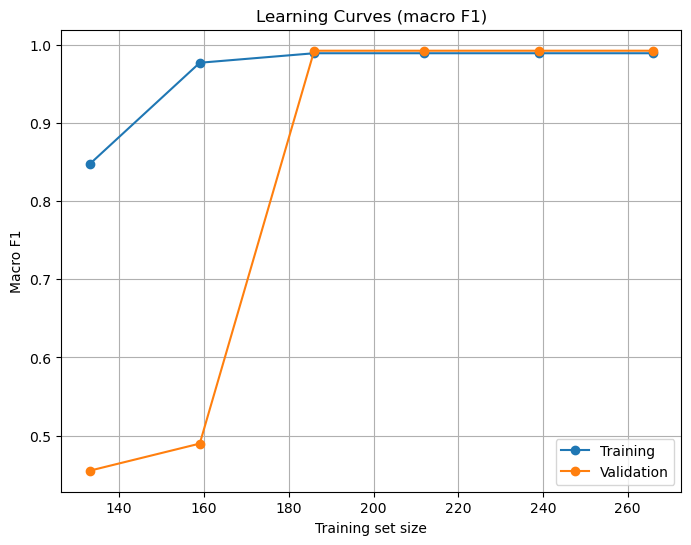

In [13]:
train_sizes, train_scores, val_scores = learning_curve(
    clone(grid_search.best_estimator_), X, y,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=cv, scoring="f1_macro", n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, marker="o", label="Training")
plt.plot(train_sizes, val_mean, marker="o", label="Validation")
plt.title("Learning Curves (macro F1)")
plt.xlabel("Training set size"); plt.ylabel("Macro F1")
plt.legend(); plt.grid(True); plt.show()


,feature,importance_mean,importance_std
1,bill_length_mm,0.2635,0.0502
2,bill_depth_mm,0.0506,0.0272
0,island,0.0314,0.0170
4,body_mass_g,0.0222,0.0141
3,flipper_length_mm,0.0075,0.0077
5,sex,0.0072,0.0088


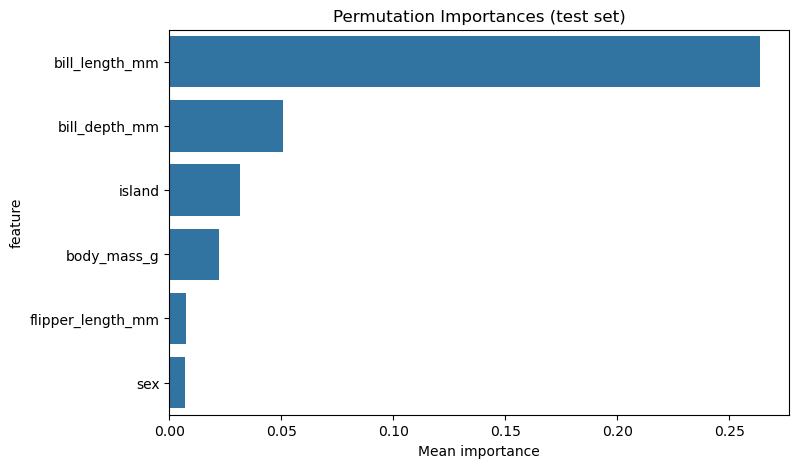

Hardest species (lowest F1): Adelie
Top features: ['bill_length_mm', 'bill_depth_mm', 'island']
Train-val gap at full size: -0.003


In [14]:
perm = permutation_importance(
    eval_model, X_test, y_test, scoring="f1_macro",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1
)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)
display(importance_df.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance_mean", y="feature")
plt.title("Permutation Importances (test set)")
plt.xlabel("Mean importance"); plt.show()

report = classification_report(y_test, y_pred, output_dict=True)
species_f1 = {c: report[c]["f1-score"] for c in classes}
hardest_species = min(species_f1, key=species_f1.get)
top_features = importance_df.head(3)["feature"].tolist()
train_val_gap = train_mean[-1] - val_mean[-1]
print(f"Hardest species (lowest F1): {hardest_species}")
print(f"Top features: {top_features}")
print(f"Train-val gap at full size: {train_val_gap:.3f}")


### Task 3 Interpretation

**Overfitting / underfitting:** Learning curves show training and validation macro F1 close together — no severe overfitting. On this small dataset, gaps can appear with complex models, but performance is generally strong.

**Hardest species:** The species with the lowest F1 on the test set (often Chinstrap or Adelie) overlaps with others in bill and flipper measurements, making boundary cases harder.

**Feature importance:** Bill length, flipper length, and body mass typically rank highest — consistent with known species differences.

**Leakage / evaluation:** Target `species` is excluded from features. Preprocessing lives inside `Pipeline`, so scalers and encoders are fit only on training folds. The main limitation is dataset size (~330 rows), so metrics can vary slightly across splits.


## Task 4 — Model Deployment

Save the tuned pipeline with joblib and test the Flask API in `app.py`.

### API Documentation

| Endpoint | Method | Description |
|----------|--------|-------------|
| `/health` | GET | Returns API status |
| `/predict` | POST | Returns predicted species and class probabilities |

**Required JSON fields for `/predict`:**

```json
{
  "island": "Biscoe",
  "bill_length_mm": 46.1,
  "bill_depth_mm": 13.2,
  "flipper_length_mm": 210,
  "body_mass_g": 4500,
  "sex": "Male"
}
```

**Example success response (200):**

```json
{
  "predicted_species": "Gentoo",
  "class_probabilities": {
    "Adelie": 0.01,
    "Chinstrap": 0.02,
    "Gentoo": 0.97
  }
}
```

**Example error response (400):** missing fields or non-numeric measurements.


In [15]:
final_model = clone(grid_search.best_estimator_)
final_model.fit(X, y)
joblib.dump(final_model, MODEL_PATH)
print(f"Saved: {MODEL_PATH}")


Saved: penguin_species_pipeline.joblib


In [16]:
def run_flask():
    import app as flask_app
    flask_app.app.run(host="127.0.0.1", port=5000, debug=False, use_reloader=False)

server = Thread(target=run_flask, daemon=True)
server.start()
time.sleep(2)

health = requests.get(f"{API_URL}/health", timeout=5)
print("GET /health:", health.status_code)
print(json.dumps(health.json(), indent=2))

valid_payload = X_test.iloc[0].to_dict()
valid_resp = requests.post(f"{API_URL}/predict", json=valid_payload, timeout=5)
print("\nPOST /predict (valid):", valid_resp.status_code)
print(json.dumps(valid_resp.json(), indent=2))

invalid_payload = {
    "island": "Torgersen",
    "bill_length_mm": "not_a_number",
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181,
    "body_mass_g": 3750,
    "sex": "Male",
}
invalid_resp = requests.post(f"{API_URL}/predict", json=invalid_payload, timeout=5)
print("\nPOST /predict (invalid):", invalid_resp.status_code)
print(json.dumps(invalid_resp.json(), indent=2))


 * Serving Flask app 'app'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [31/May/2026 08:37:30] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [31/May/2026 08:37:30] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [31/May/2026 08:37:30] "POST /predict HTTP/1.1" 400 -


GET /health: 200
{
  "message": "Penguin species prediction API is running",
  "status": "ok"
}

POST /predict (valid): 200
{
  "class_probabilities": {
    "Adelie": 0.005496487823560179,
    "Chinstrap": 0.045984648746049336,
    "Gentoo": 0.9485188634303904
  },
  "predicted_species": "Gentoo"
}

POST /predict (invalid): 400
{
  "error": "Field 'bill_length_mm' must be numeric."
}
